In [35]:
!pip install yfinance

In [36]:
# ──  Data Collection ──────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

df = yf.download("AAPL", start="2019-01-01", end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.index.name = 'Date'
print("✓ Data downloaded | Shape:", df.shape)

[*********************100%***********************]  1 of 1 completed

✓ Data downloaded | Shape: (1258, 5)


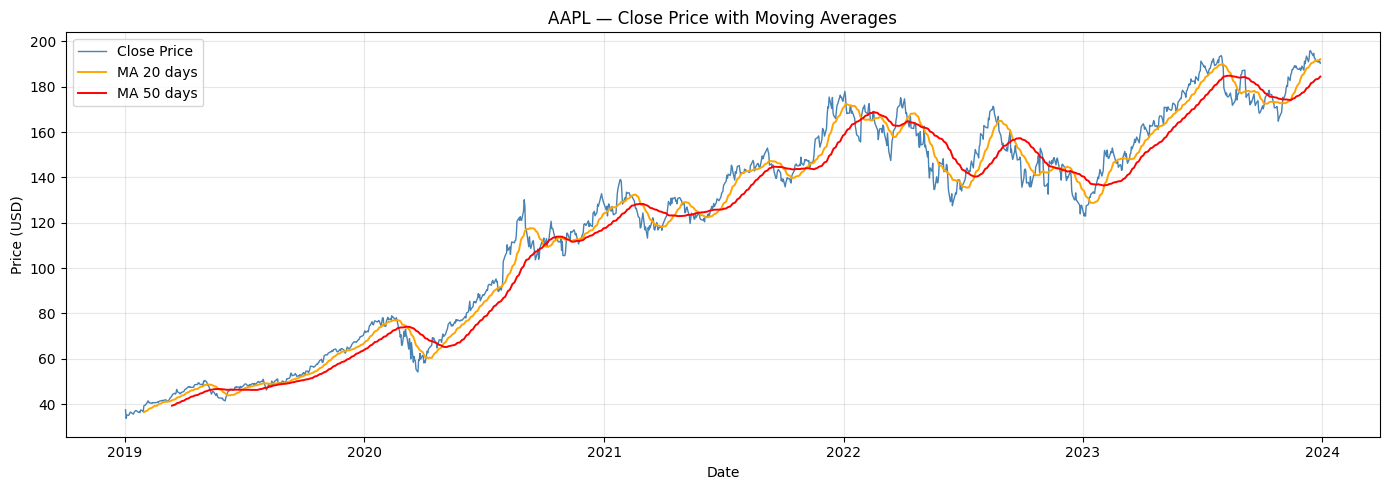

In [37]:
# ──  EDA ──────────────────────────────────────────
df['Daily_Return'] = df['Close'].pct_change() * 100

df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close Price', color='steelblue', linewidth=1.0)
plt.plot(df['MA_20'], label='MA 20 days',  color='orange',    linewidth=1.4)
plt.plot(df['MA_50'], label='MA 50 days',  color='red',       linewidth=1.4)
plt.title('AAPL — Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [38]:
# ── Feature Engineering ─────────────────────────
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

def calculate_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs       = avg_gain / avg_loss
    return    100 - (100 / (1 + rs))

df['RSI_14']      = calculate_rsi(df['Close'])
df['MACD']        = df['EMA_12'] - df['EMA_26']
df['MACD_Hist']   = df['MACD'] - df['MACD'].ewm(span=9, adjust=False).mean()
df['Price_Range'] = df['High'] - df['Low']
df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std()
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)
df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(window=20).mean()

df.dropna(inplace=True)
print(" Shape:", df.shape)

 Shape: (1209, 19)


In [39]:
#  Preprocessing ────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

features = [
    'Close', 'MA_20', 'MA_50', 'EMA_12',
    'RSI_14', 'MACD', 'MACD_Hist',
    'Price_Range', 'Volatility_20',
    'Lag_1', 'Lag_2', 'Lag_3', 'Volume_Ratio'
]

scaler      = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y    = create_sequences(scaled_data, 60)
split   = int(len(X) * 0.8)
X_train = X[:split];  X_test  = X[split:]
y_train = y[:split];  y_test  = y[split:]


print("  X_train:", X_train.shape)
print("  X_test :", X_test.shape)

  X_train: (919, 60, 13)
  X_test : (230, 60, 13)


In [40]:
# ──  Model Building ───────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_flat, y_train)
lr_pred  = lr_model.predict(X_test_flat)
print(f"✓ Linear Regression → MAE: {mean_absolute_error(y_test, lr_pred):.4f}")

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_flat, y_train)
rf_pred  = rf_model.predict(X_test_flat)
print(f"✓ Random Forest     → MAE: {mean_absolute_error(y_test, rf_pred):.4f}")

# LSTM
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(
    X_train, y_train,
    epochs=100, batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True)],
    verbose=1
)
lstm_pred = model.predict(X_test)
print(f"✓ LSTM              → MAE: {mean_absolute_error(y_test, lstm_pred.flatten()):.4f}")

✓ Linear Regression → MAE: 0.0151
✓ Random Forest     → MAE: 0.0518
Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - loss: 0.0383 - val_loss: 0.0054
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0067 - val_loss: 0.0022
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0043 - val_loss: 0.0014
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0037 - val_loss: 0.0019
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - loss: 0.0040 - val_loss: 0.0031
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0032 - val_loss: 0.0020
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0031 - val_loss: 0.0024
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - loss: 0.0028 - val_loss: 0.0016
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - loss:

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
✓ LSTM              → MAE: 0.0260


Linear Regression    → MAE: $2.33 | RMSE: $3.04 | MAPE: 1.36%
Random Forest        → MAE: $7.99 | RMSE: $10.99 | MAPE: 4.35%
LSTM                 → MAE: $4.02 | RMSE: $4.69 | MAPE: 2.29%


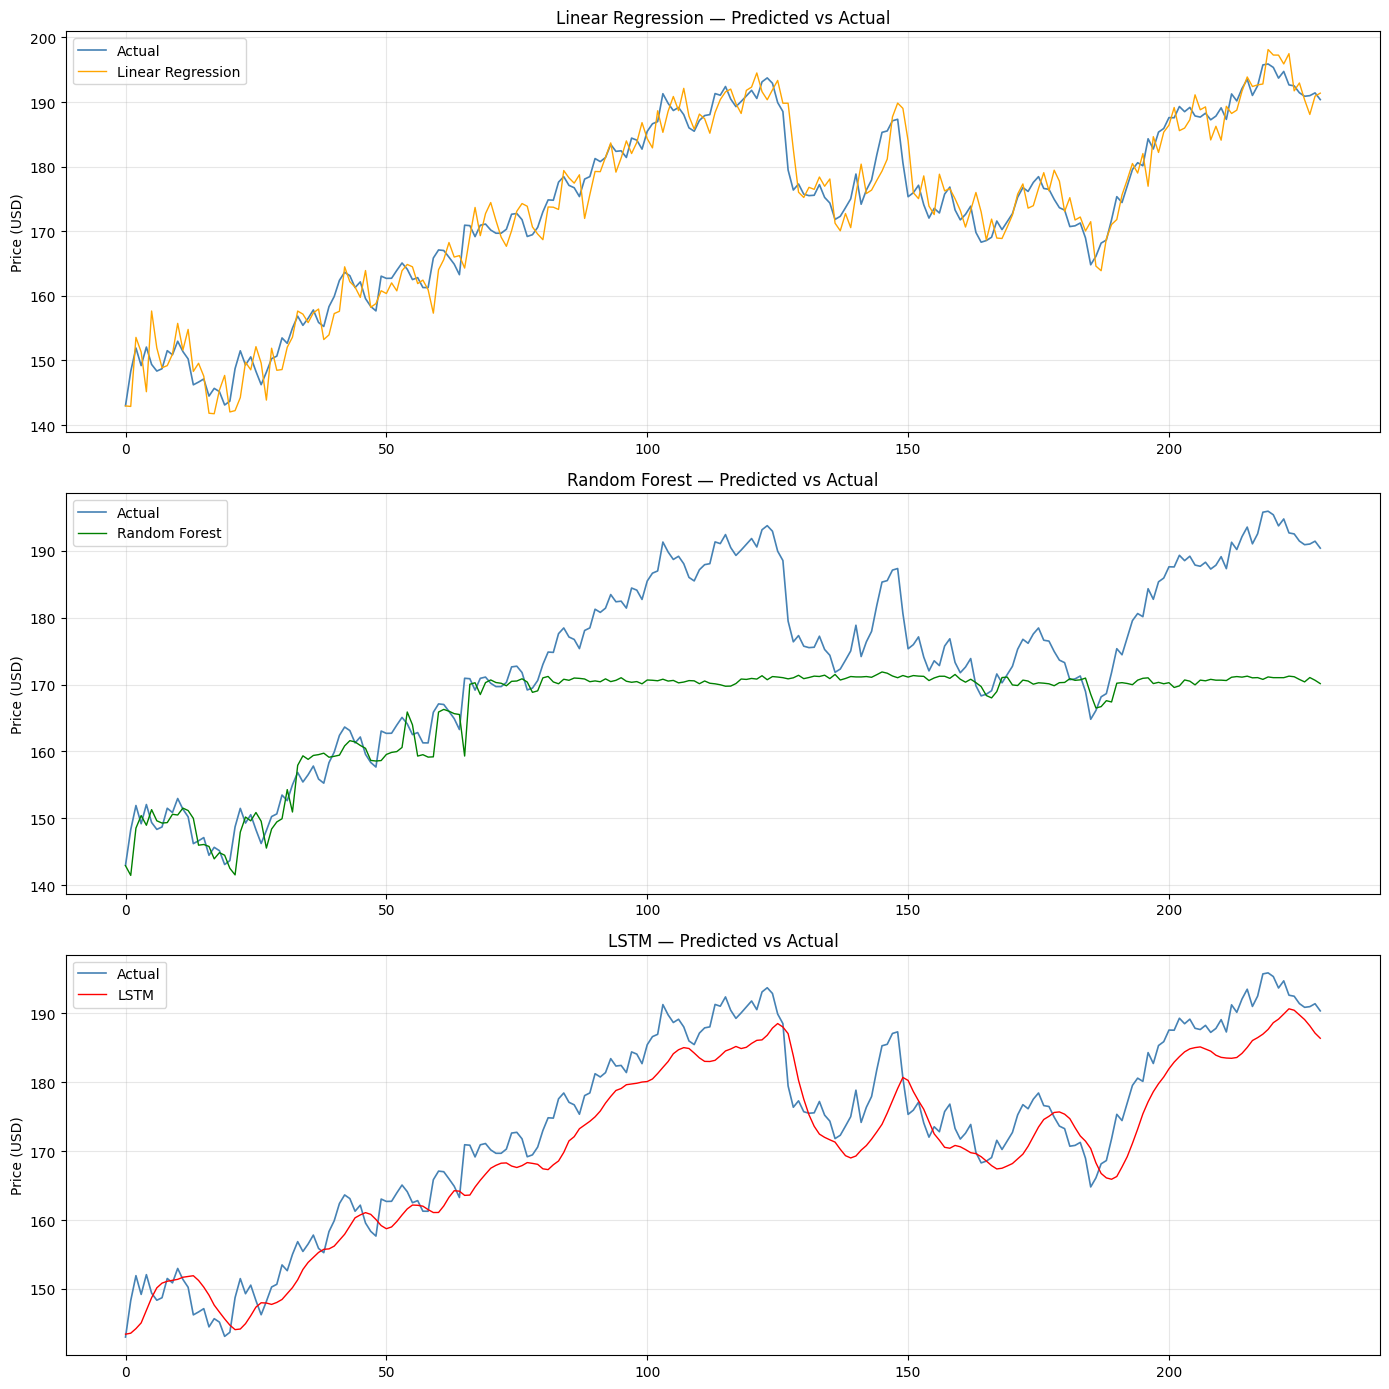

In [41]:
# ──  Evaluation ───────────────────────────────────
def inverse_close(vals, scaler, n=13):
    dummy = np.zeros((len(vals), n))
    dummy[:, 0] = vals
    return scaler.inverse_transform(dummy)[:, 0]

y_actual         = inverse_close(y_test,              scaler)
lr_pred_actual   = inverse_close(lr_pred,             scaler)
rf_pred_actual   = inverse_close(rf_pred,             scaler)
lstm_pred_actual = inverse_close(lstm_pred.flatten(), scaler)

def evaluate(name, actual, pred):
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    print(f"{name:20s} → MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | MAPE: {mape:.2f}%")
    return mae, rmse, mape

print("=" * 60)
lr_s   = evaluate("Linear Regression", y_actual, lr_pred_actual)
rf_s   = evaluate("Random Forest",     y_actual, rf_pred_actual)
lstm_s = evaluate("LSTM",              y_actual, lstm_pred_actual)

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
for ax, (name, pred, color) in zip(axes, [
    ("Linear Regression", lr_pred_actual,   'orange'),
    ("Random Forest",     rf_pred_actual,   'green'),
    ("LSTM",              lstm_pred_actual, 'red')
]):
    ax.plot(y_actual, label='Actual',     color='steelblue', linewidth=1.2)
    ax.plot(pred,     label=f'{name}',    color=color,       linewidth=1.0)
    ax.set_title(f'{name} — Predicted vs Actual')
    ax.set_ylabel('Price (USD)')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [42]:
!pip install streamlit pyngrok -q
print("✓ Installed")

✓ Installed


In [43]:
app_code = '''
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from datetime import date
import warnings
warnings.filterwarnings("ignore")

st.set_page_config(page_title="Stock Price Prediction", page_icon="📈", layout="wide")
st.title("📈 Stock Price Prediction")

st.sidebar.header("⚙️ Settings")
ticker      = st.sidebar.text_input("Stock Ticker", value="AAPL").upper()
today       = date.today()
default_start = date(today.year - 5, today.month, today.day)
start_date  = st.sidebar.date_input("Start Date", value=default_start)
end_date    = st.sidebar.date_input("End Date",   value=today)
date_diff   = (end_date - start_date).days

if date_diff < 400:
    st.sidebar.warning(f"⚠️ Only {date_diff} days data — atleast it should 400!")

model_choice = st.sidebar.selectbox("Select Model",
    ["All Models", "Linear Regression", "Random Forest", "LSTM"])
run = st.sidebar.button("▶ Run Prediction", disabled=(date_diff < 400))

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    rs    = gain.rolling(period).mean() / loss.rolling(period).mean()
    return 100 - (100 / (1 + rs))

def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

def inverse_close(vals, scaler, n=13):
    dummy = np.zeros((len(vals), n))
    dummy[:, 0] = vals
    return scaler.inverse_transform(dummy)[:, 0]

def get_metrics(actual, pred):
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

if run:
    with st.spinner(f"{ticker} data is downloading..."):
        df = yf.download(ticker, start=str(start_date),
                         end=str(end_date), auto_adjust=True)
        df.columns = df.columns.get_level_values(0)
        df.columns.name = None

    if df.empty:
        st.error(" Required data not found")
        st.stop()

    if len(df) < 200:
        st.error(f"❌ only {len(df)} days found . Revers Start date.")
        st.stop()

    st.success(f"✓ {len(df)} trading days downloaded for {ticker}")

    with st.spinner("Features are developing..."):
        df["Daily_Return"]  = df["Close"].pct_change() * 100
        df["MA_20"]         = df["Close"].rolling(20).mean()
        df["MA_50"]         = df["Close"].rolling(50).mean()
        df["EMA_12"]        = df["Close"].ewm(span=12, adjust=False).mean()
        df["EMA_26"]        = df["Close"].ewm(span=26, adjust=False).mean()
        df["RSI_14"]        = calculate_rsi(df["Close"])
        df["MACD"]          = df["EMA_12"] - df["EMA_26"]
        df["MACD_Hist"]     = df["MACD"] - df["MACD"].ewm(span=9, adjust=False).mean()
        df["Price_Range"]   = df["High"] - df["Low"]
        df["Volatility_20"] = df["Daily_Return"].rolling(20).std()
        df["Lag_1"]         = df["Close"].shift(1)
        df["Lag_2"]         = df["Close"].shift(2)
        df["Lag_3"]         = df["Close"].shift(3)
        df["Volume_Ratio"]  = df["Volume"] / df["Volume"].rolling(20).mean()
        df.dropna(inplace=True)

    features = ["Close","MA_20","MA_50","EMA_12","RSI_14",
                "MACD","MACD_Hist","Price_Range","Volatility_20",
                "Lag_1","Lag_2","Lag_3","Volume_Ratio"]

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[features])
    X, y   = create_sequences(scaled, 60)
    split  = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    X_tr_f = X_train.reshape(X_train.shape[0], -1)
    X_te_f = X_test.reshape(X_test.shape[0], -1)
    y_actual = inverse_close(y_test, scaler)

    results = {}
    colors  = {"Linear Regression":"steelblue",
               "Random Forest":"green", "LSTM":"red"}

    if model_choice in ["All Models", "Linear Regression"]:
        with st.spinner("Linear Regression is training..."):
            lr = LinearRegression()
            lr.fit(X_tr_f, y_train)
            results["Linear Regression"] = inverse_close(lr.predict(X_te_f), scaler)

    if model_choice in ["All Models", "Random Forest"]:
        with st.spinner("Random Forest is training..."):
            rf = RandomForestRegressor(100, random_state=42, n_jobs=-1)
            rf.fit(X_tr_f, y_train)
            results["Random Forest"] = inverse_close(rf.predict(X_te_f), scaler)

    if model_choice in ["All Models", "LSTM"]:
        with st.spinner("LSTM is training (2-3 mins)..."):
            m = Sequential([
                Input(shape=(X_train.shape[1], X_train.shape[2])),
                LSTM(128, return_sequences=True),
                Dropout(0.2),
                LSTM(64, return_sequences=False),
                Dropout(0.2),
                Dense(1)
            ])
            m.compile(optimizer="adam", loss="mse")
            m.fit(X_train, y_train, epochs=100, batch_size=32,
                  validation_split=0.1,
                  callbacks=[EarlyStopping(monitor="val_loss",
                             patience=10, restore_best_weights=True)],
                  verbose=0)
            results["LSTM"] = inverse_close(m.predict(X_test).flatten(), scaler)

    st.subheader("📊 Model Performance")
    rows = []
    cols = st.columns(len(results))
    for col, (name, pred) in zip(cols, results.items()):
        mae, rmse, mape = get_metrics(y_actual, pred)
        rows.append({"Model":name, "MAE ($)":round(mae,2),
                     "RMSE ($)":round(rmse,2), "MAPE (%)":round(mape,2)})
        with col:
            st.metric(f"{name} MAE",  f"${mae:.2f}")
            st.metric(f"{name} RMSE", f"${rmse:.2f}")
            st.metric(f"{name} MAPE", f"{mape:.2f}%")

    st.subheader("📋 Comparison Table")
    st.dataframe(pd.DataFrame(rows), use_container_width=True)

    st.subheader("📈 Predicted vs Actual")
    for name, pred in results.items():
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(y_actual, label="Actual",     color="steelblue", linewidth=1.2)
        ax.plot(pred,     label=f"{name}",    color=colors[name], linewidth=1.0)
        ax.set_title(f"{ticker} — {name}")
        ax.set_xlabel("Test Days")
        ax.set_ylabel("Price (USD)")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout()
        st.pyplot(fig); plt.close()

    with st.expander("🔍 Raw Data"):
        st.dataframe(df.tail(20), use_container_width=True)
'''

with open("stock_app.py", "w") as f:
    f.write(app_code)
print("✓ stock_app.py ready!")

✓ stock_app.py ready!


In [44]:
!ngrok authtoken 3FLp7BYgCo1SEsw4FGbupdQau7A_5sZX4g2dg8hHAZ4N7G7vC

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [45]:
from pyngrok import ngrok
import subprocess, time

ngrok.kill()
subprocess.Popen(
    ["streamlit", "run", "stock_app.py",
     "--server.port=8501", "--server.headless=true"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(5)
url = ngrok.connect(8501)
print(" App is Live:", url)

 App is Live: NgrokTunnel: "https://dinner-romp-epidemic.ngrok-free.dev" -> "http://localhost:8501"


# New Section